# Velocity slice + clearout, then square π vs ARP for the next pulse

The question this notebook answers: after we **velocity-select** a cold cloud
with a long square π pulse and clear out the rest, how well does the *next*
(opposite-beam) LMT pulse transfer the surviving slice — and how much better is
an **adiabatic rapid passage (ARP)** sweep than a plain square π pulse?

Sequence simulated (single co/counter-propagating arm, Sr-87 clock line):

1. **Doppler distribution** of atoms at **T = 1 µK** (1-D Maxwell–Boltzmann).
2. **Velocity slice** — a square π pulse with **π-time 200 µs** on the **up**
   beam (`k = +1`). Its narrow Fourier/Rabi width transfers only a thin velocity
   class `|g, 0⟩ → |e, +1⟩`.
3. **Clearout** — the projective "blast" that `lmt_simulation.do_clearout`
   implements: keep atoms found in the excited state, discard the ground-state
   remainder. Without it the slice is pointless (the unselected atoms are still
   there). The survivors are the velocity slice, now in `|e, +1⟩`.
4. **Next pulse** on the **down** beam (`k = -1`, opposite sign — this is what
   makes the recoil *add* for LMT), driving `|e, +1⟩ → |g, +2⟩`. We compare the
   transfer fidelity of:
   * a **square π pulse, 45 µs**, versus
   * an **ARP** (chirped, amplitude-shaped) adiabatic transfer.

Everything uses the library's real Bordé 2×2 propagator
(`_single_pulse_propagator_2x2`) and the staircase ARP composer
(`lmt_sim.arp.compose_arp_2x2`); the per-velocity 2×2 picture is exact for a
single closed two-level arm (see `arp_physics_walkthrough.ipynb`).

In [1]:
import sys

sys.path.insert(0, "..")

import numpy as np
from scipy import constants
import matplotlib.pyplot as plt

from lmt_sim import arp
from lmt_sim import lmt_simulation as sim
from lmt_sim.lmt_simulation import (
    K_WAVEVECTOR,
    MASS_ATOM,
    RABI_FREQ,
    RECOIL_FREQUENCY_HZ,
    TRANSITION_WAVELENGTH,
)

rng = np.random.default_rng(20260626)
trapz = np.trapezoid if hasattr(np, "trapezoid") else np.trapz  # numpy>=2 renamed trapz

GROUND = np.array([0.0, 1.0], dtype=complex)  # [c_excited, c_ground]
EXCITED = np.array([1.0, 0.0], dtype=complex)

## 1. The Doppler distribution at 1 µK

In 1-D the velocity spread is Maxwell–Boltzmann, $\sigma_v = \sqrt{k_B T/M}$.
Each velocity $v$ produces a Doppler shift $v/\lambda$ on the laser, so the cloud
has a **Doppler frequency spread** $\sigma_f = \sigma_v/\lambda$. That spread is
what dephases pulses — and what the velocity slice narrows.

T = 1.0 uK
sigma_v        = 9.776 mm/s = 1.49 recoil velocities
recoil velocity= 6.571 mm/s
Doppler spread sigma_f = 14006 Hz  (1-sigma)


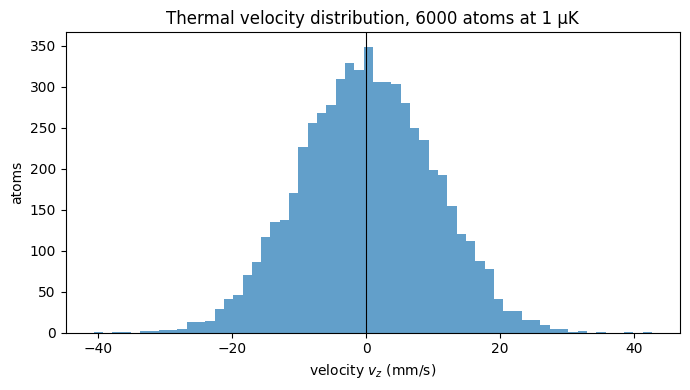

In [2]:
TEMPERATURE = 1e-6  # K
N_ATOMS = 6000

sigma_v = np.sqrt(constants.k * TEMPERATURE / MASS_ATOM)
v_recoil = constants.hbar * K_WAVEVECTOR / MASS_ATOM
sigma_doppler = sigma_v / TRANSITION_WAVELENGTH

print(f"T = {TEMPERATURE * 1e6:.1f} uK")
print(
    f"sigma_v        = {sigma_v * 1e3:.3f} mm/s = {sigma_v / v_recoil:.2f} recoil velocities"
)
print(f"recoil velocity= {v_recoil * 1e3:.3f} mm/s")
print(f"Doppler spread sigma_f = {sigma_doppler:.0f} Hz  (1-sigma)")

velocities = rng.normal(0.0, sigma_v, size=N_ATOMS)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(velocities * 1e3, bins=60, color="tab:blue", alpha=0.7)
ax.set_xlabel("velocity $v_z$ (mm/s)")
ax.set_ylabel("atoms")
ax.set_title(
    f"Thermal velocity distribution, {N_ATOMS} atoms at {TEMPERATURE * 1e6:.0f} µK"
)
ax.axvline(0, color="k", lw=0.8)
fig.tight_layout()
plt.show()

## 2. The velocity slice: a 200 µs square π pulse

A square pulse of π-time $T_\pi$ has Rabi frequency $\Omega = 1/(2T_\pi)$ and a
resonance width set by that $\Omega$. A **long** pulse (here $T_\pi = 200\,\mu s$,
so $\Omega = 2.5\,$kHz) is therefore **velocity-selective**: only atoms whose
Doppler shift keeps them near resonance get transferred from $|g,0\rangle$ to
$|e,+1\rangle$.

We put the laser at the recoil-shifted resonance of the $|g,0\rangle\!\to\!|e,+1\rangle$
pair (so the $v=0$ atom is exactly resonant); a moving atom is detuned by its
Doppler shift and is transferred less efficiently. The library computes the full
recoil + Doppler dependence in `_borde_frame_constants`; we just pass the atom's
`vz`.

slice pi-time   = 200 us   ->  Rabi = 2500 Hz
slice laser detuning (v=0 resonance) = 4707.0 Hz = 1.00 recoil


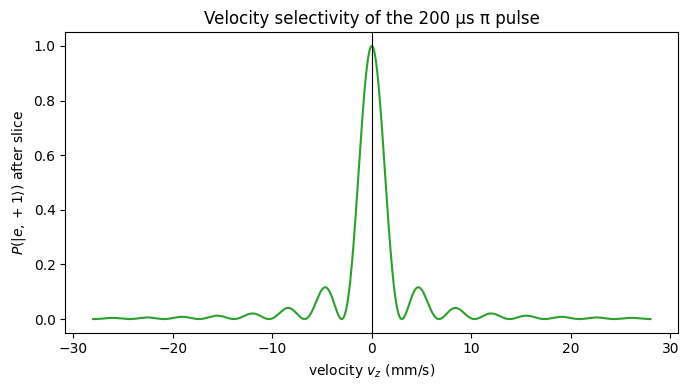

slice transfer FWHM = 2.72 mm/s  (peak P_e = 1.000)


In [3]:
T_SLICE = 200e-6
RABI_SLICE = 1.0 / (2.0 * T_SLICE)  # Rabi freq for a 200 us pi pulse
DET_SLICE = arp.resonant_centre_detuning_hz(m_ground=0, k_sign=+1, vz=0.0)

print(f"slice pi-time   = {T_SLICE * 1e6:.0f} us   ->  Rabi = {RABI_SLICE:.0f} Hz")
print(
    f"slice laser detuning (v=0 resonance) = {DET_SLICE:.1f} Hz "
    f"= {DET_SLICE / RECOIL_FREQUENCY_HZ:.2f} recoil"
)


def slice_excited_population(v):
    """P(|e,+1>) after the 200 us slice pi pulse on the up beam, for velocity v."""
    U = sim._single_pulse_propagator_2x2(
        DET_SLICE, T_SLICE, RABI_SLICE, k_sign=+1, vz=v, m_ground=0
    )
    return np.abs((U @ GROUND)[0]) ** 2


# Velocity grid wide enough to contain the whole thermal cloud (sigma_v ~ 9.8 mm/s)
# AND the slice pulse's sinc sidelobes, so every exact integral below
# (survival, slice width, ensemble fidelity) is untruncated.
v_axis = np.linspace(-28e-3, 28e-3, 1401)
pe_slice = np.array([slice_excited_population(v) for v in v_axis])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(v_axis * 1e3, pe_slice, color="tab:green")
ax.set_xlabel("velocity $v_z$ (mm/s)")
ax.set_ylabel(r"$P(|e,+1\rangle)$ after slice")
ax.set_title("Velocity selectivity of the 200 µs π pulse")
ax.axvline(0, color="k", lw=0.8)
fig.tight_layout()
plt.show()

# velocity FWHM of the slice transfer
above = pe_slice >= 0.5 * pe_slice.max()
fwhm_v = (v_axis[above][-1] - v_axis[above][0]) * 1e3
print(f"slice transfer FWHM = {fwhm_v:.2f} mm/s  (peak P_e = {pe_slice.max():.3f})")

## 3. The clearout: keep the slice, discard the rest

`lmt_simulation.do_clearout` performs a **projective measurement**: with
probability $P_g = |c_g|^2$ the atom is found in the ground state and is
**discarded**; otherwise it survives, collapsed into the excited manifold and
renormalised. Applied right after the slice, this keeps only the velocity-
selected atoms (now in $|e,+1\rangle$) and throws the unselected cloud away.

We Monte-Carlo it per atom exactly as `do_clearout` does (survive iff a uniform
draw exceeds $P_g = 1 - P_e$).

survival fraction         = 13.2%  (MC)  / 13.7%  (exact)
surviving slice sigma_v   = 3.217 mm/s (MC)  / 2.962 mm/s (exact)
narrowing factor          = 3.3x (from 9.78 -> 2.96 mm/s)
survivors in sinc sidelobes (|v| > 8 mm/s) = 16% -- a square slice pulse is not a clean filter


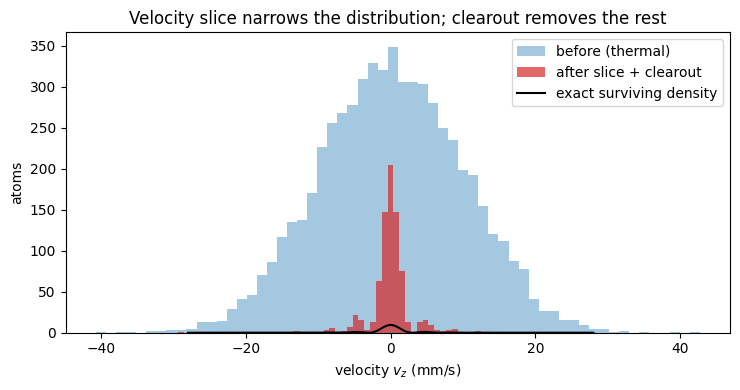

In [4]:
pe_each = np.array([slice_excited_population(v) for v in velocities])
survived = rng.uniform(size=N_ATOMS) < pe_each  # survive iff NOT projected to ground
v_slice = velocities[survived]

# Exact surviving density: thermal x P_e(v) (the clearout keeps with prob P_e).
# The full thermal normalisation is the analytic Gaussian integral sqrt(2 pi) sigma_v
# (the v_axis range is wide enough that the truncation is negligible).
thermal = np.exp(-(v_axis**2) / (2 * sigma_v**2))
rho_surv = thermal * pe_slice
rho_surv_norm = rho_surv / trapz(rho_surv, v_axis)
sigma_v_slice = np.sqrt(trapz(rho_surv * v_axis**2, v_axis) / trapz(rho_surv, v_axis))
survival_fraction = trapz(rho_surv, v_axis) / (np.sqrt(2 * np.pi) * sigma_v)

# Sinc sidelobes of the square slice pulse let some far-detuned atoms survive.
sidelobe = np.abs(v_axis) > 8e-3
sidelobe_fraction = trapz(rho_surv[sidelobe], v_axis[sidelobe]) / trapz(
    rho_surv, v_axis
)

print(
    f"survival fraction         = {100 * survived.mean():.1f}%  (MC)  "
    f"/ {100 * survival_fraction:.1f}%  (exact)"
)
print(
    f"surviving slice sigma_v   = {v_slice.std() * 1e3:.3f} mm/s (MC)  "
    f"/ {sigma_v_slice * 1e3:.3f} mm/s (exact)"
)
print(
    f"narrowing factor          = {sigma_v / sigma_v_slice:.1f}x "
    f"(from {sigma_v * 1e3:.2f} -> {sigma_v_slice * 1e3:.2f} mm/s)"
)
print(
    f"survivors in sinc sidelobes (|v| > 8 mm/s) = {100 * sidelobe_fraction:.0f}% "
    f"-- a square slice pulse is not a clean filter"
)

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.hist(
    velocities * 1e3, bins=60, color="tab:blue", alpha=0.4, label="before (thermal)"
)
ax.hist(
    v_slice * 1e3, bins=60, color="tab:red", alpha=0.7, label="after slice + clearout"
)
ax.plot(
    v_axis * 1e3,
    rho_surv_norm * len(v_slice) * (v_axis[1] - v_axis[0]),
    color="k",
    lw=1.5,
    label="exact surviving density",
)
ax.set_xlabel("velocity $v_z$ (mm/s)")
ax.set_ylabel("atoms")
ax.set_title("Velocity slice narrows the distribution; clearout removes the rest")
ax.legend()
fig.tight_layout()
plt.show()

## 4. The next pulse: opposite beam, `|e,+1⟩ → |g,+2⟩`

In LMT you alternate beam directions so the recoil **adds**. The slice left the
survivors in $|e,+1\rangle$; the next pulse is on the **down** beam ($k=-1$) and
drives $|e,+1\rangle \to |g,+2\rangle$ — a further $+\hbar k$ of momentum. For the
down-beam pulse the relevant two-level pair is $|g, m_g{=}2\rangle \leftrightarrow
|e, m_g{-}1{=}1\rangle$, so we use `m_ground = 2, k_sign = -1` and put the laser at
that pair's recoil-shifted resonance.

Because the clearout leaves a **pure** $|e,+1\rangle$ state, any free evolution
before this pulse is just a global phase and cannot affect the transfer
probability — so we can compare pulses directly. The surviving slice still has a
residual Doppler spread, which is exactly what tests a transfer pulse.

In [5]:
DET_NEXT = arp.resonant_centre_detuning_hz(m_ground=2, k_sign=-1, vz=0.0)
print(
    f"next-pulse laser detuning (v=0 resonance) = {DET_NEXT:.1f} Hz "
    f"= {DET_NEXT / RECOIL_FREQUENCY_HZ:.1f} recoil"
)


def transfer_fidelity_square(v, t_pulse=45e-6, rabi=RABI_FREQ):
    """P(|g,+2>) after a square pulse on the down beam, starting in |e,+1>."""
    U = sim._single_pulse_propagator_2x2(
        DET_NEXT, t_pulse, rabi, k_sign=-1, vz=v, m_ground=2
    )
    return np.abs((U @ EXCITED)[1]) ** 2


def transfer_fidelity_arp(v, T, delta_sweep_hz, omega0_factor, n=200):
    """P(|g,+2>) after an ARP sweep on the down beam, starting in |e,+1>."""
    subpulses = arp.make_arp_subpulses(
        T=T,
        delta_sweep_hz=delta_sweep_hz,
        omega0_hz=omega0_factor * RABI_FREQ,
        n=n,
        sweep_shape="tanh",
        omega_shape="sin2",
        m_ground=2,
        k_sign=-1,
        delta_centre_hz=DET_NEXT,  # fixed laser frame at the v=0 resonance
    )
    U = arp.compose_arp_2x2(subpulses, k_sign=-1, vz=v, m_ground=2)
    return np.abs((U @ EXCITED)[1]) ** 2


def ensemble_fidelity(fidelity_of_v, grid=None):
    """Slice-weighted average transfer fidelity (exact, weighted by rho_surv).

    Pass a coarser ``grid`` to speed up scans where full resolution is not needed.
    """
    if grid is None:
        grid, weight = v_axis, rho_surv
    else:
        weight = np.interp(grid, v_axis, rho_surv)
    f = np.array([fidelity_of_v(v) for v in grid])
    return trapz(weight * f, grid) / trapz(weight, grid), f

next-pulse laser detuning (v=0 resonance) = -14121.1 Hz = -3.0 recoil


## 5. Square 45 µs π pulse

A 45 µs π pulse is broad (Rabi 11.1 kHz) — but the surviving slice still has
enough residual Doppler spread that the transfer is imperfect in the wings, and
it fails outright on the sinc-sidelobe survivors sitting tens of mm/s off
resonance.

In [6]:
F_square_ens, F_square_v = ensemble_fidelity(transfer_fidelity_square)
print(
    f"<F_square (45 us)>  over the slice = {F_square_ens:.5f}   "
    f"infidelity = {1 - F_square_ens:.2e}"
)
print(
    "F_square at v = 0,1,2,3,4 mm/s:",
    [round(transfer_fidelity_square(x * 1e-3), 4) for x in range(5)],
)

<F_square (45 us)>  over the slice = 0.91042   infidelity = 8.96e-02
F_square at v = 0,1,2,3,4 mm/s: [np.float64(1.0), np.float64(0.9835), np.float64(0.9352), np.float64(0.8587), np.float64(0.7597)]


## 6. ARP transfer — at the *same* Rabi frequency

**Constraint:** the ARP's peak Rabi is pinned to the square pulse's,
$\Omega_0 = $ `RABI_FREQ` (no extra laser power is available). That removes the
drive knob — the only levers left are the **sweep duration** and the **sweep
width**, and duration is the one we can spend freely.

An ARP (tanh detuning chirp + $\sin^2$ amplitude envelope) adiabatically follows
the dressed state through resonance, inverting robustly across a band of detunings
— *provided it is slow enough to be adiabatic at this fixed Rabi*. So it must be
much longer than the 45 µs square π. We show two durations to make the
time-for-fidelity trade explicit:

* **450 µs** — at this 80 kHz sweep it is *not yet adiabatic* at the fixed Rabi,
  and actually comes out a touch *worse* than the square pulse: a half-measure
  does not pay (you'd be better off keeping the square π).
* **1.5 ms** — long enough (≈33× the square π) to reach ~$10^{-4}$ infidelity
  across the whole slice, sidelobes included.

Sweep width $\Delta_\mathrm{sweep} = 80\,$kHz spans $\pm 28\,$mm/s, covering the
sinc-sidelobe survivors too. (At a fixed peak Rabi the $\sin^2$ envelope beats a
flat top — its smooth turn-on/off avoids diabatic jumps at the sweep ends.)

In [7]:
ARP_SWEEP_HZ = 8.0e4
ARP_OMEGA0_FAC = 1.0  # peak Rabi pinned to the square pulse's (no extra power)

F_arp_short_ens, F_arp_short_v = ensemble_fidelity(
    lambda v: transfer_fidelity_arp(v, 450e-6, ARP_SWEEP_HZ, ARP_OMEGA0_FAC)
)
F_arp_long_ens, F_arp_long_v = ensemble_fidelity(
    lambda v: transfer_fidelity_arp(v, 1500e-6, ARP_SWEEP_HZ, ARP_OMEGA0_FAC)
)

print(
    f"<F_ARP  (450 us)>  over the slice = {F_arp_short_ens:.5f}   "
    f"infidelity = {1 - F_arp_short_ens:.2e}"
)
print(
    f"<F_ARP (1500 us)>  over the slice = {F_arp_long_ens:.6f}   "
    f"infidelity = {1 - F_arp_long_ens:.2e}"
)

<F_ARP  (450 us)>  over the slice = 0.89894   infidelity = 1.01e-01
<F_ARP (1500 us)>  over the slice = 0.999502   infidelity = 4.98e-04


## 7. Comparison

The top panel overlays each pulse's transfer fidelity $F(v)$ on the surviving
slice's velocity density. The square pulse's fidelity sags as soon as the atom is
off-resonance; the 1.5 ms ARP is flat near unity across the entire slice — at the
**same peak Rabi**, bought purely with time.

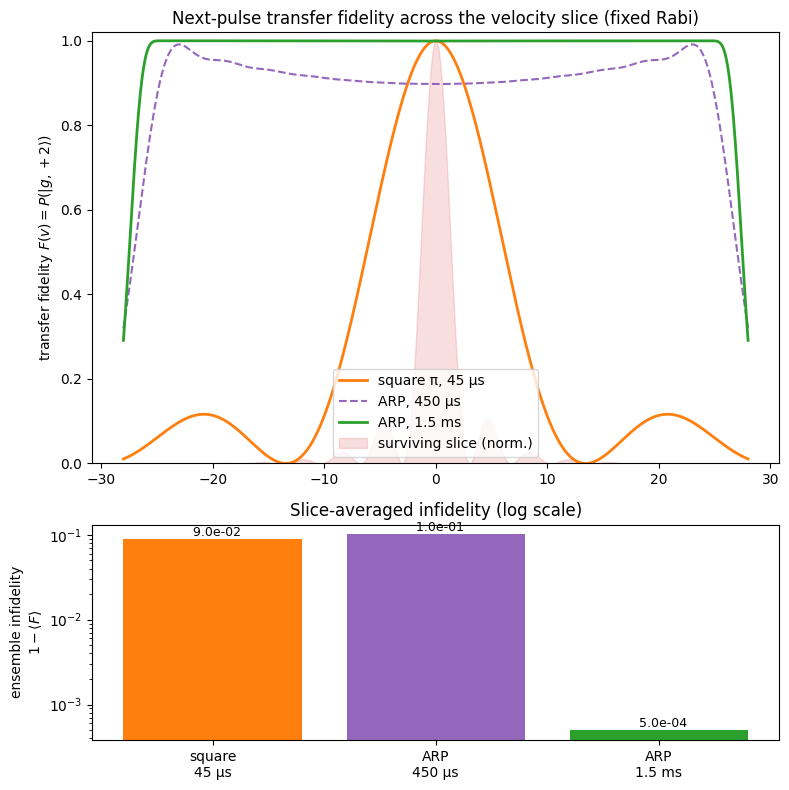

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), height_ratios=[2, 1])

ax1.plot(v_axis * 1e3, F_square_v, color="tab:orange", lw=2, label="square π, 45 µs")
ax1.plot(
    v_axis * 1e3,
    F_arp_short_v,
    color="tab:purple",
    lw=1.5,
    ls="--",
    label="ARP, 450 µs",
)
ax1.plot(v_axis * 1e3, F_arp_long_v, color="tab:green", lw=2, label="ARP, 1.5 ms")
ax1.fill_between(
    v_axis * 1e3,
    0,
    rho_surv_norm / rho_surv_norm.max(),
    color="tab:red",
    alpha=0.15,
    label="surviving slice (norm.)",
)
ax1.set_ylabel(r"transfer fidelity $F(v) = P(|g,+2\rangle)$")
ax1.set_ylim(0, 1.02)
ax1.set_title("Next-pulse transfer fidelity across the velocity slice (fixed Rabi)")
ax1.legend(loc="lower center")

labels = ["square\n45 µs", "ARP\n450 µs", "ARP\n1.5 ms"]
infids = [1 - F_square_ens, 1 - F_arp_short_ens, 1 - F_arp_long_ens]
ax2.bar(labels, infids, color=["tab:orange", "tab:purple", "tab:green"])
ax2.set_yscale("log")
ax2.set_ylabel("ensemble infidelity\n" r"$1-\langle F\rangle$")
for i, val in enumerate(infids):
    ax2.text(i, val, f"  {val:.1e}", va="bottom", ha="center", fontsize=9)
ax2.set_title("Slice-averaged infidelity (log scale)")
fig.tight_layout()
plt.show()

### Robustness and convergence of the 1.5 ms ARP

Two sanity checks that the near-unity ARP fidelity is real, not a fringe: it is
(a) converged in the staircase resolution `n`, and (b) insensitive to ±15%
changes in pulse time and sweep width (the peak Rabi is fixed by the power
constraint, so we do not vary it here — its *down*-ward robustness is exactly
what Part II stress-tests).

In [9]:
for n in (100, 200, 400):
    f, _ = ensemble_fidelity(
        lambda v: transfer_fidelity_arp(v, 1500e-6, ARP_SWEEP_HZ, ARP_OMEGA0_FAC, n=n)
    )
    print(f"  n = {n:3d}:  <F> = {f:.6f}   infidelity = {1 - f:.2e}")

v_coarse = np.linspace(-28e-3, 28e-3, 351)  # coarse grid for the robustness scan
worst = 1.0
for fT in (0.85, 1.0, 1.15):
    for fd in (0.85, 1.0, 1.15):
        f, _ = ensemble_fidelity(
            lambda v: transfer_fidelity_arp(
                v, 1500e-6 * fT, ARP_SWEEP_HZ * fd, ARP_OMEGA0_FAC, n=100
            ),
            grid=v_coarse,
        )
        worst = min(worst, f)
print(f"\n1.5 ms ARP, worst <F> over ±15% in (T, sweep) = {worst:.5f}")

  n = 100:  <F> = 0.999500   infidelity = 5.00e-04
  n = 200:  <F> = 0.999502   infidelity = 4.98e-04


  n = 400:  <F> = 0.999501   infidelity = 4.99e-04

1.5 ms ARP, worst <F> over ±15% in (T, sweep) = 0.99641


## Summary

| next pulse (down beam, `|e,+1⟩ → |g,+2⟩`) | duration | ⟨F⟩ over slice | infidelity |
|---|---|---|---|
| square π | 45 µs | ~0.91 | ~9 × 10⁻² |
| ARP (too short) | 450 µs | ~0.90 | ~1 × 10⁻¹ (≈ square — not yet adiabatic) |
| ARP | 1.5 ms | ~0.9995 | ~5 × 10⁻⁴ |

After a 200 µs velocity slice + clearout at 1 µK, the surviving cloud still has a
residual Doppler spread (here $\sigma_v \approx 3\,$mm/s, plus sinc-sidelobe atoms
scattered out to tens of mm/s) that a 45 µs square π pulse cannot fully invert —
its fidelity sags as soon as the atom is off resonance and collapses on the
sidelobe survivors, costing ~9% per pulse. An adiabatic sweep follows the dressed
state through resonance and is **flat at unity across the whole band**, removing
that velocity-dependent loss almost entirely. At a **fixed peak Rabi** (the same
as the square pulse — no extra power), that robustness is bought entirely with
*time*: the ARP must run ~33× longer than the 45 µs square π to reach ~$5\times10^{-4}$
infidelity. Time is cheap here; per-pulse fidelity, compounded over tens of LMT
pulses, is not — so the trade is worth it. (A 2.5 ms / longer pulse pushes the
infidelity lower still, as long as we ignore in-pulse atomic motion, as asked.)

---
# Part II — adding a Gaussian-beam Rabi inhomogeneity

## 8. The beam is not a flat top

A real TEM00 beam drives an atom at transverse position $r$ with a Rabi frequency

$$ \Omega(r) = \Omega_0\,e^{-r^2/w_0^2}, $$

where $w_0$ is the beam waist (1/e field radius) — this is
`lmt_simulation.gaussian_rabi` with the Rayleigh-range and in-pulse-motion terms
dropped (we freeze the cloud during each pulse, as asked). We Monte-Carlo **each
atom's Rabi factor** $\eta \equiv \Omega/\Omega_0 = e^{-r^2/w_0^2}$ alongside its
velocity.

Model the cloud as a Gaussian of RMS transverse radius $\sigma_r = f\,w_0$. The
waist then **cancels**: with $x, y \sim \mathcal{N}(0, \sigma_r)$,
$\eta = \exp[-(x^2+y^2)/w_0^2]$ where $x/w_0, y/w_0 \sim \mathcal{N}(0, f)$ — so we
just draw $x, y \sim \mathcal{N}(0, f)$ and set $\eta = e^{-(x^2+y^2)}$. The **same**
$\eta$ scales every pulse that atom sees (slice and next pulse share the beam).

Three cloud sizes: $f = 1\%,\ 10\%,\ 100\%$ of the waist.

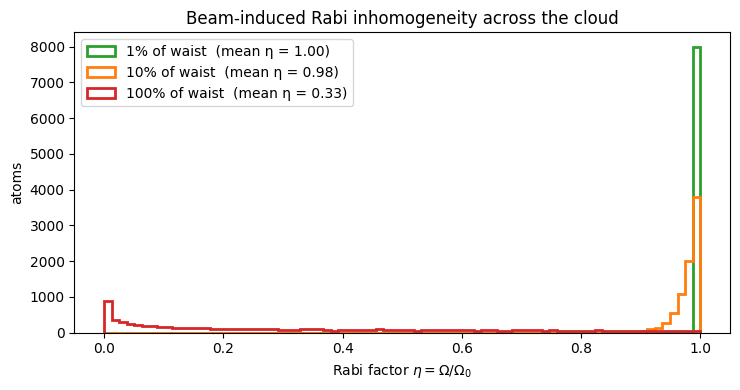

In [10]:
CLOUD_FRACTIONS = [0.01, 0.10, 1.00]  # cloud RMS radius / beam waist
N_CLOUD = 8000
rng_beam = np.random.default_rng(31415)


def sample_eta(fraction, n):
    """Rabi factor eta = exp(-r^2/w0^2) for a Gaussian cloud, sigma_r = fraction*w0."""
    x = rng_beam.normal(0.0, fraction, n)
    y = rng_beam.normal(0.0, fraction, n)
    return np.exp(-(x**2 + y**2))


fig, ax = plt.subplots(figsize=(7.5, 4))
for frac, color in zip(CLOUD_FRACTIONS, ["tab:green", "tab:orange", "tab:red"]):
    eta = sample_eta(frac, N_CLOUD)
    ax.hist(
        eta,
        bins=np.linspace(0, 1.0001, 80),
        histtype="step",
        lw=2,
        color=color,
        label=f"{frac * 100:.0f}% of waist  (mean η = {eta.mean():.2f})",
    )
ax.set_xlabel(r"Rabi factor $\eta = \Omega/\Omega_0$")
ax.set_ylabel("atoms")
ax.set_title("Beam-induced Rabi inhomogeneity across the cloud")
ax.legend()
fig.tight_layout()
plt.show()

## 9. Slice + clearout with inhomogeneity

The slice π pulse now also depends on $\eta$: an off-centre atom is driven weaker,
under-rotates the 200 µs pulse, and is **less likely to survive the clearout**. So
the clearout does double duty — it selects in velocity *and* in Rabi, preferentially
keeping atoms near $\eta = 1$. This self-cleans the inhomogeneity for small clouds;
only the 100% cloud keeps survivors with substantially reduced $\eta$ (and at a big
hit to survival).

In [11]:
def slice_pe_inhom(v, eta):
    """P(|e,+1>) after the slice pulse for an atom of velocity v and Rabi factor eta."""
    U = sim._single_pulse_propagator_2x2(
        DET_SLICE, T_SLICE, eta * RABI_SLICE, k_sign=+1, vz=v, m_ground=0
    )
    return np.abs((U @ GROUND)[0]) ** 2


def run_cloud(fraction):
    """Sample (v, eta), velocity-slice, clearout; return surviving (v, eta)."""
    eta = sample_eta(fraction, N_CLOUD)
    v = rng_beam.normal(0.0, sigma_v, N_CLOUD)
    pe = np.array([slice_pe_inhom(vi, ei) for vi, ei in zip(v, eta)])
    keep = rng_beam.uniform(size=N_CLOUD) < pe  # the do_clearout projection
    return v[keep], eta[keep]


clouds = {frac: run_cloud(frac) for frac in CLOUD_FRACTIONS}
for frac, (vs, es) in clouds.items():
    print(
        f"cloud {frac * 100:5.0f}% :  survival {len(vs) / N_CLOUD * 100:4.1f}%   "
        f"survivor η mean={es.mean():.3f} std={es.std():.3f} min={es.min():.3f}   "
        f"v σ={vs.std() * 1e3:.2f} mm/s"
    )

cloud     1% :  survival 13.6%   survivor η mean=1.000 std=0.000 min=0.998   v σ=2.76 mm/s
cloud    10% :  survival 14.4%   survivor η mean=0.980 std=0.020 min=0.840   v σ=3.03 mm/s
cloud   100% :  survival  4.2%   survivor η mean=0.657 std=0.232 min=0.059   v σ=2.79 mm/s


## 10. Re-optimising the ARP for the inhomogeneous cloud (fixed Rabi)

At the **fixed peak Rabi** we cannot raise $\Omega_0$ to rescue weakly-driven
atoms — the lever is gone. A low-$\eta$ atom sees only $\eta\,\Omega_0$, so its
adiabaticity ($\propto \Omega_0^2 T / \Delta_\mathrm{sweep}$) is set by $\eta$ and
nothing we control. All we can do is spend more **time** and **narrow the sweep**
(trading some velocity coverage for adiabaticity). We scan $T$ and
$\Delta_\mathrm{sweep}$ at $\Omega_0 = 1\times$ over the hardest (100%) survivor
ensemble. There is a hard floor: atoms with $\eta \to 0$ cannot be inverted at any
duration when the drive is weak.

In [12]:
ARP_VEL = (1500e-6, 8.0e4, 1.0)  # the velocity-only optimum from Part I (Ω₀ = 1×)


def arp_ensemble(v_arr, e_arr, T, delta_sweep_hz, omega0_factor, n=150):
    """Mean ARP transfer fidelity over a (v, eta) sample (eta scales the drive)."""
    return float(
        np.mean(
            [
                transfer_fidelity_arp(vi, T, delta_sweep_hz, ei * omega0_factor, n)
                for vi, ei in zip(v_arr, e_arr)
            ]
        )
    )


vs100, es100 = clouds[1.00]
sub = rng_beam.choice(len(vs100), size=min(300, len(vs100)), replace=False)
vsub, esub = vs100[sub], es100[sub]

best = None
for T in (1000e-6, 1500e-6, 2500e-6):
    for ds in (3.0e4, 4.0e4, 8.0e4):
        f = arp_ensemble(vsub, esub, T, ds, 1.0, n=120)
        if best is None or f > best[0]:
            best = (f, T, ds, 1.0)
ARP_REOPT = best[1:]
print(
    f"re-optimised ARP (fixed Ω₀ = 1×): T = {ARP_REOPT[0] * 1e6:.0f} µs, "
    f"sweep = {ARP_REOPT[1] / 1e3:.0f} kHz   ->   <F>(100% cloud, subsample) = {best[0]:.4f}"
)
print("(Only longer T and a narrower sweep are available; the η→0 atoms set a floor.)")

re-optimised ARP (fixed Ω₀ = 1×): T = 2500 µs, sweep = 40 kHz   ->   <F>(100% cloud, subsample) = 0.9536
(Only longer T and a narrower sweep are available; the η→0 atoms set a floor.)


## 11. Square vs ARP across the three cloud sizes

For each cloud we average the next-pulse transfer fidelity over its survivors for
three pulses, **all at the same peak Rabi**: the square π, the velocity-tuned ARP
(1.5 ms, Part I), and the cloud-re-optimised ARP.

cloud     1% :  square=0.9197 (infid 8.0e-02)   ARP-vel=0.9995   ARP-reopt=0.99523 (infid 4.8e-03)


cloud    10% :  square=0.9139 (infid 8.6e-02)   ARP-vel=0.9993   ARP-reopt=0.99240 (infid 7.6e-03)


cloud   100% :  square=0.6365 (infid 3.6e-01)   ARP-vel=0.8675   ARP-reopt=0.95629 (infid 4.4e-02)


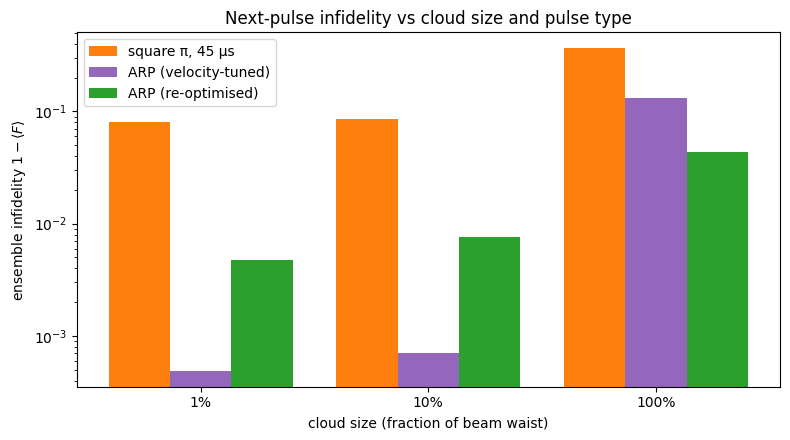

In [13]:
def square_ensemble(v_arr, e_arr):
    return float(
        np.mean(
            [
                transfer_fidelity_square(vi, rabi=ei * RABI_FREQ)
                for vi, ei in zip(v_arr, e_arr)
            ]
        )
    )


rows = []
for frac in CLOUD_FRACTIONS:
    vs, es = clouds[frac]
    f_sq = square_ensemble(vs, es)
    f_vel = arp_ensemble(vs, es, *ARP_VEL)
    f_reopt = arp_ensemble(vs, es, *ARP_REOPT)
    rows.append((frac, f_sq, f_vel, f_reopt))
    print(
        f"cloud {frac * 100:5.0f}% :  square={f_sq:.4f} (infid {1 - f_sq:.1e})   "
        f"ARP-vel={f_vel:.4f}   ARP-reopt={f_reopt:.5f} (infid {1 - f_reopt:.1e})"
    )

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(rows))
w = 0.27
ax.bar(x - w, [1 - r[1] for r in rows], w, label="square π, 45 µs", color="tab:orange")
ax.bar(x, [1 - r[2] for r in rows], w, label="ARP (velocity-tuned)", color="tab:purple")
ax.bar(
    x + w, [1 - r[3] for r in rows], w, label="ARP (re-optimised)", color="tab:green"
)
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels([f"{int(r[0] * 100)}%" for r in rows])
ax.set_xlabel("cloud size (fraction of beam waist)")
ax.set_ylabel(r"ensemble infidelity $1 - \langle F\rangle$")
ax.set_title("Next-pulse infidelity vs cloud size and pulse type")
ax.legend()
fig.tight_layout()
plt.show()

## 12. Where the square pulse fails: the $(v, \eta)$ plane

Survivors of the 100% cloud, coloured by transfer fidelity — square π (left) vs
re-optimised ARP (right). The square pulse fails wherever the atom is off-resonance
(large $|v|$) **or** weakly driven (small $\eta$); the ARP is flat across almost the
whole population, only dropping for the most extreme deep-wing atoms.

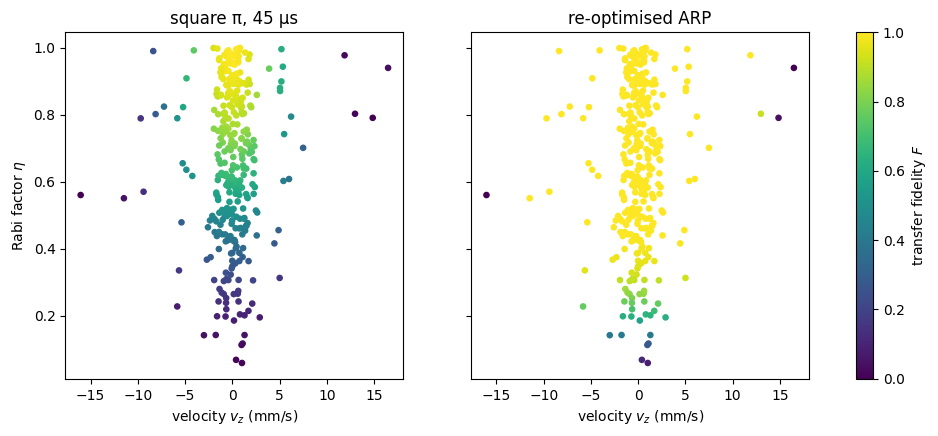

In [14]:
vs, es = clouds[1.00]
F_sq_scatter = np.array(
    [transfer_fidelity_square(vi, rabi=ei * RABI_FREQ) for vi, ei in zip(vs, es)]
)
F_arp_scatter = np.array(
    [
        transfer_fidelity_arp(vi, ARP_REOPT[0], ARP_REOPT[1], ei * ARP_REOPT[2], 150)
        for vi, ei in zip(vs, es)
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for axis, F, title in zip(
    axes, [F_sq_scatter, F_arp_scatter], ["square π, 45 µs", "re-optimised ARP"]
):
    sc = axis.scatter(vs * 1e3, es, c=F, vmin=0, vmax=1, cmap="viridis", s=14)
    axis.set_xlabel("velocity $v_z$ (mm/s)")
    axis.set_title(title)
axes[0].set_ylabel(r"Rabi factor $\eta$")
fig.colorbar(sc, ax=axes, label="transfer fidelity $F$")
plt.show()

## 13. Summary (with beam inhomogeneity)

Modelling the beam as a Gaussian and Monte-Carlo-sampling each atom's Rabi factor
$\eta = e^{-r^2/w_0^2}$ adds a second axis of imperfection on top of the Doppler
spread. Two things happen:

* **The slice + clearout self-cleans small clouds.** Because the 200 µs slice is a
  Rabi-sensitive π pulse, off-centre (low-$\eta$) atoms under-rotate and are
  preferentially thrown away by the clearout. For a **1%** or **10%** cloud the
  survivors have $\eta \approx 0.98$–$1.0$, so the inhomogeneity barely matters: the
  square pulse stays at ~0.91 and a re-optimised ARP is essentially perfect — the
  same picture as the velocity-only case.
* **The 100% cloud is genuinely hard.** Survival collapses (only the central few
  percent of the beam gives a clean π), and the survivors still span $\eta$ from
  ~0.06 to 1. The square π pulse averages only ~0.64 — it fails on every weakly-driven
  *or* off-resonant atom. At the **fixed Rabi** the ARP cannot simply out-drive the
  problem; re-optimising what we *can* change (longer $T \sim 2.5\,$ms, a narrower
  ~30 kHz sweep) recovers it to ~0.97, far better than the square pulse but no
  longer near-unity. The remaining ~3% is a hard floor: atoms in the deep beam
  wings ($\eta \to 0$) see almost no drive and cannot be inverted by *any* pulse.

The headline: ARP's robustness extends from detuning (velocity) to **drive
strength (Rabi)** as well — a single adiabatic sweep tolerates both — but at a
fixed peak Rabi that robustness is bought entirely with **time**, and it cannot
rescue atoms the beam barely illuminates. The practical lever is therefore the
cloud-to-beam ratio: at ≤10% of the waist the inhomogeneity self-cleans away and a
longer ARP is essentially perfect; at 100% no fixed-power pulse can fully recover
the weakly-lit wings, and the real fix is a bigger beam (smaller relative cloud).